<a href="https://colab.research.google.com/github/anjaliikakde/sar_images_colorization/blob/main/SARIMG_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 2: Install required library
!pip install rasterio

In [ ]:
# # Step 3: Extract Patches
# import rasterio
# import numpy as np
# import os
# from rasterio.windows import Window

# def extract_patches(sar_path, optical_path, save_dir, patch_size=256):
#     os.makedirs(f"{save_dir}/SAR", exist_ok=True)
#     os.makedirs(f"{save_dir}/Optical", exist_ok=True)
#     count = 0

#     with rasterio.open(sar_path) as sar:
#         with rasterio.open(optical_path) as opt:
#             H, W = sar.height, sar.width
#             for i in range(0, H - patch_size, patch_size):
#                 for j in range(0, W - patch_size, patch_size):
#                     win = Window(j, i, patch_size, patch_size)
#                     sar_patch = sar.read(1, window=win)
#                     opt_patch = opt.read([1,2,3], window=win)

#                     if sar_patch.min() == 0 or opt_patch.min() == 0:
#                         continue

#                     np.save(f"{save_dir}/SAR/patch_{count}.npy", sar_patch)
#                     np.save(f"{save_dir}/Optical/patch_{count}.npy", opt_patch)
#                     count += 1

#     print(f"✅ Extracted {count} pairs successfully!")

# # Step 4: Run it
# extract_patches(
#     sar_path='/content/drive/MyDrive/SAR_Dataset/SAR_Image.tif',
#     optical_path='/content/drive/MyDrive/SAR_Dataset/Optical_Image.tif',
#     save_dir='/content/drive/MyDrive/SAR_Dataset/Patches'
# )

In [ ]:
# # =============================================
# # STEP 3: Install & Import Libraries
# # =============================================
# !pip install torch torchvision -q

# import torch
# from torch.utils.data import Dataset, DataLoader
# import numpy as np
# import os

In [ ]:
# # =============================================
# # STEP 4: Dataset Class
# # =============================================
# class SARDataset(Dataset):
#     def __init__(self, sar_dir, optical_dir):
#         self.sar_dir = sar_dir
#         self.optical_dir = optical_dir
#         self.files = sorted([f for f in os.listdir(sar_dir) if f.endswith('.npy')])
#         print(f"Found {len(self.files)} pairs")

#     def __len__(self):
#         return len(self.files)

#     def __getitem__(self, idx):
#         fname = self.files[idx]

#         # Load patches
#         sar = np.load(os.path.join(self.sar_dir, fname)).astype(np.float32)
#         opt = np.load(os.path.join(self.optical_dir, fname)).astype(np.float32)

#         # Normalize SAR to [0, 1]  (SAR range is roughly -25 to 5 dB)
#         sar = np.clip(sar, -25, 5)
#         sar = (sar + 25) / 30.0

#         # Normalize Optical to [-1, 1]  (GAN expects this range)
#         opt = np.clip(opt, 0, 3000)
#         opt = (opt / 3000.0) * 2 - 1

#         # Add channel dim to SAR → (1, 256, 256)
#         sar = torch.tensor(sar).unsqueeze(0)

#         # Optical → (3, 256, 256)
#         opt = torch.tensor(opt)
#         if opt.shape[0] != 3:
#             opt = opt.permute(2, 0, 1)

#         return sar, opt

# # =============================================
# # STEP 5: Test the Dataset
# # =============================================
# sar_dir     = '/content/drive/MyDrive/SAR_Dataset/Patches/SAR'
# optical_dir = '/content/drive/MyDrive/SAR_Dataset/Patches/Optical'

# dataset = SARDataset(sar_dir, optical_dir)
# dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# # Check one batch
# sar_batch, opt_batch = next(iter(dataloader))
# print(f"SAR batch shape:     {sar_batch.shape}")   # → [4, 1, 256, 256]
# print(f"Optical batch shape: {opt_batch.shape}")   # → [4, 3, 256, 256]
# print("✅ Dataset ready for GAN training!")

Found 1575 pairs
SAR batch shape:     torch.Size([4, 1, 256, 256])
Optical batch shape: torch.Size([4, 3, 256, 256])
✅ Dataset ready for GAN training!


In [ ]:
import torch
import torch.nn as nn

# =============================================
# U-Net Generator
# =============================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, down=True, use_bn=True, dropout=False):
        super().__init__()
        layers = []
        if down:
            layers.append(nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False))
        else:
            layers.append(nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False))
        if use_bn:
            layers.append(nn.BatchNorm2d(out_ch))
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)
        self.down = down

    def forward(self, x):
        if self.down:
            return torch.relu(self.block(x))
        else:
            return torch.relu(self.block(x))


class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (SAR: 1 channel in)
        self.e1 = nn.Conv2d(1, 64, 4, 2, 1)           # 128x128
        self.e2 = ConvBlock(64,  128)                   # 64x64
        self.e3 = ConvBlock(128, 256)                   # 32x32
        self.e4 = ConvBlock(256, 512)                   # 16x16
        self.e5 = ConvBlock(512, 512)                   # 8x8
        self.e6 = ConvBlock(512, 512)                   # 4x4
        self.e7 = ConvBlock(512, 512)                   # 2x2

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, 4, 2, 1),               # 1x1
            nn.ReLU()
        )

        # Decoder with skip connections
        self.d1 = ConvBlock(512,  512, down=False, dropout=True)   # 2x2
        self.d2 = ConvBlock(1024, 512, down=False, dropout=True)   # 4x4
        self.d3 = ConvBlock(1024, 512, down=False, dropout=True)   # 8x8
        self.d4 = ConvBlock(1024, 512, down=False)                 # 16x16
        self.d5 = ConvBlock(1024, 256, down=False)                 # 32x32
        self.d6 = ConvBlock(512,  128, down=False)                 # 64x64
        self.d7 = ConvBlock(256,  64,  down=False)                 # 128x128

        # Output layer (3 channels = RGB)
        self.output = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),        # 256x256
            nn.Tanh()                                    # [-1, 1]
        )

    def forward(self, x):
        # Encode
        e1 = self.e1(x)
        e2 = self.e2(e1)
        e3 = self.e3(e2)
        e4 = self.e4(e3)
        e5 = self.e5(e4)
        e6 = self.e6(e5)
        e7 = self.e7(e6)
        b  = self.bottleneck(e7)

        # Decode with skip connections (U-Net style)
        d1 = self.d1(b)
        d2 = self.d2(torch.cat([d1, e7], dim=1))
        d3 = self.d3(torch.cat([d2, e6], dim=1))
        d4 = self.d4(torch.cat([d3, e5], dim=1))
        d5 = self.d5(torch.cat([d4, e4], dim=1))
        d6 = self.d6(torch.cat([d5, e3], dim=1))
        d7 = self.d7(torch.cat([d6, e2], dim=1))

        return self.output(torch.cat([d7, e1], dim=1))


# =============================================
# Test Generator
# =============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

G = Generator().to(device)
test_input = torch.randn(1, 1, 256, 256).to(device)
test_output = G(test_input)
print(f"Input shape:  {test_input.shape}")   # [1, 1, 256, 256]
print(f"Output shape: {test_output.shape}")  # [1, 3, 256, 256]
print("✅ Generator built successfully!")

Using device: cpu
Input shape:  torch.Size([1, 1, 256, 256])
Output shape: torch.Size([1, 3, 256, 256])
✅ Generator built successfully!


In [ ]:
# =============================================
# PatchGAN Discriminator
# =============================================

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        # Input: SAR (1ch) + Optical (3ch) = 4 channels
        self.model = nn.Sequential(
            # Layer 1 - no batchnorm on first layer
            nn.Conv2d(4, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            # Layer 2
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # Layer 3
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            # Layer 4
            nn.Conv2d(256, 512, 4, 1, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            # Output - 1 channel patch prediction
            nn.Conv2d(512, 1, 4, 1, 1)
            # No sigmoid - using BCEWithLogitsLoss
        )

    def forward(self, sar, optical):
        # Concatenate SAR + Optical along channel dim
        x = torch.cat([sar, optical], dim=1)   # [B, 4, 256, 256]
        return self.model(x)


# =============================================
# Test Discriminator
# =============================================
D = Discriminator().to(device)

fake_sar     = torch.randn(1, 1, 256, 256).to(device)
fake_optical = torch.randn(1, 3, 256, 256).to(device)

output = D(fake_sar, fake_optical)
print(f"SAR input shape:     {fake_sar.shape}")
print(f"Optical input shape: {fake_optical.shape}")
print(f"Discriminator output shape: {output.shape}")  # [1, 1, 30, 30]
print("✅ Discriminator built successfully!")

# =============================================
# Model Summary
# =============================================
total_G = sum(p.numel() for p in G.parameters())
total_D = sum(p.numel() for p in D.parameters())
print(f"\nGenerator parameters:     {total_G:,}")
print(f"Discriminator parameters: {total_D:,}")

SAR input shape:     torch.Size([1, 1, 256, 256])
Optical input shape: torch.Size([1, 3, 256, 256])
Discriminator output shape: torch.Size([1, 1, 30, 30])
✅ Discriminator built successfully!

Generator parameters:     54,412,483
Discriminator parameters: 2,766,657


In [ ]:
# import torch.optim as optim
# from torchvision.utils import save_image
# import time

# # =============================================
# # Loss Functions & Optimizers
# # =============================================
# criterion_GAN = nn.BCEWithLogitsLoss()
# criterion_L1  = nn.L1Loss()

# optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
# optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

# # Loss weights
# LAMBDA_L1 = 100

# # =============================================
# # Training Configuration
# # =============================================
# NUM_EPOCHS  = 50
# save_dir    = '/content/drive/MyDrive/SAR_Dataset/Results'
# os.makedirs(save_dir, exist_ok=True)
# os.makedirs(f"{save_dir}/checkpoints", exist_ok=True)

# # =============================================
# # Training Loop
# # =============================================
# print("🚀 Starting Training...")

# for epoch in range(NUM_EPOCHS):
#     G.train()
#     D.train()
#     epoch_loss_G = 0
#     epoch_loss_D = 0
#     start = time.time()

#     for i, (sar, optical) in enumerate(dataloader):
#         sar     = sar.to(device)
#         optical = optical.to(device)

#         # ------------------------------------
#         # Train Discriminator
#         # ------------------------------------
#         optimizer_D.zero_grad()

#         # Real loss
#         real_pred = D(sar, optical)
#         real_labels = torch.ones_like(real_pred).to(device)
#         loss_D_real = criterion_GAN(real_pred, real_labels)

#         # Fake loss
#         fake_optical = G(sar)
#         fake_pred = D(sar, fake_optical.detach())
#         fake_labels = torch.zeros_like(fake_pred).to(device)
#         loss_D_fake = criterion_GAN(fake_pred, fake_labels)

#         loss_D = (loss_D_real + loss_D_fake) * 0.5
#         loss_D.backward()
#         optimizer_D.step()

#         # ------------------------------------
#         # Train Generator
#         # ------------------------------------
#         optimizer_G.zero_grad()

#         fake_optical = G(sar)
#         pred_fake    = D(sar, fake_optical)
#         real_labels  = torch.ones_like(pred_fake).to(device)

#         loss_G_GAN = criterion_GAN(pred_fake, real_labels)
#         loss_G_L1  = criterion_L1(fake_optical, optical) * LAMBDA_L1
#         loss_G     = loss_G_GAN + loss_G_L1

#         loss_G.backward()
#         optimizer_G.step()

#         epoch_loss_G += loss_G.item()
#         epoch_loss_D += loss_D.item()

#     # ------------------------------------
#     # Log every epoch
#     # ------------------------------------
#     elapsed = time.time() - start
#     avg_G = epoch_loss_G / len(dataloader)
#     avg_D = epoch_loss_D / len(dataloader)
#     print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
#           f"Loss_G: {avg_G:.4f}  "
#           f"Loss_D: {avg_D:.4f}  "
#           f"Time: {elapsed:.1f}s")

#     # ------------------------------------
#     # Save sample images every 5 epochs
#     # ------------------------------------
#     if (epoch + 1) % 5 == 0:
#         G.eval()
#         with torch.no_grad():
#             sample_sar, sample_opt = next(iter(dataloader))
#             sample_sar = sample_sar.to(device)
#             fake = G(sample_sar)

#             # Denormalize to [0,1] for saving
#             fake = (fake + 1) / 2
#             real = (sample_opt + 1) / 2

#             save_image(fake, f"{save_dir}/fake_epoch_{epoch+1}.png")
#             save_image(real, f"{save_dir}/real_epoch_{epoch+1}.png")
#             print(f"💾 Saved sample images at epoch {epoch+1}")

#     # ------------------------------------
#     # Save model checkpoint every 10 epochs
#     # ------------------------------------
#     if (epoch + 1) % 10 == 0:
#         torch.save(G.state_dict(),
#             f"{save_dir}/checkpoints/G_epoch_{epoch+1}.pth")
#         torch.save(D.state_dict(),
#             f"{save_dir}/checkpoints/D_epoch_{epoch+1}.pth")
#         print(f"💾 Saved checkpoint at epoch {epoch+1}")

# print("✅ Training Complete!")

In [ ]:
# import matplotlib.pyplot as plt
# import torch
# import numpy as np

# G.eval()

# # Load one batch
# sar_batch, real_optical = next(iter(dataloader))
# sar_batch    = sar_batch.to(device)
# real_optical = real_optical.to(device)

# with torch.no_grad():
#     fake_optical = G(sar_batch)

# # Denormalize
# def denorm(tensor):
#     return (tensor + 1) / 2

# # Plot first 4 samples
# fig, axes = plt.subplots(3, 4, figsize=(16, 10))
# titles = ['SAR Input', 'Generated (Fake)', 'Ground Truth (Real)']

# for i in range(4):
#     # SAR
#     sar_img = sar_batch[i].cpu().squeeze().numpy()
#     axes[0, i].imshow(sar_img, cmap='gray')
#     axes[0, i].set_title(f'SAR Input {i+1}')
#     axes[0, i].axis('off')

#     # Fake
#     fake_img = denorm(fake_optical[i]).cpu().permute(1,2,0).numpy()
#     fake_img = np.clip(fake_img, 0, 1)
#     axes[1, i].imshow(fake_img)
#     axes[1, i].set_title(f'Generated {i+1}')
#     axes[1, i].axis('off')

#     # Real
#     real_img = denorm(real_optical[i]).cpu().permute(1,2,0).numpy()
#     real_img = np.clip(real_img, 0, 1)
#     axes[2, i].imshow(real_img)
#     axes[2, i].set_title(f'Ground Truth {i+1}')
#     axes[2, i].axis('off')

# plt.suptitle('SAR Colorization Results', fontsize=16, fontweight='bold')
# plt.tight_layout()
# plt.savefig('/content/drive/MyDrive/SAR_Dataset/Results/final_results.png', dpi=150)
# plt.show()
# print("✅ Results saved to Drive!")

SAR min/max: 0.000 / 0.607
Optical min/max: 0.124 / 1.000


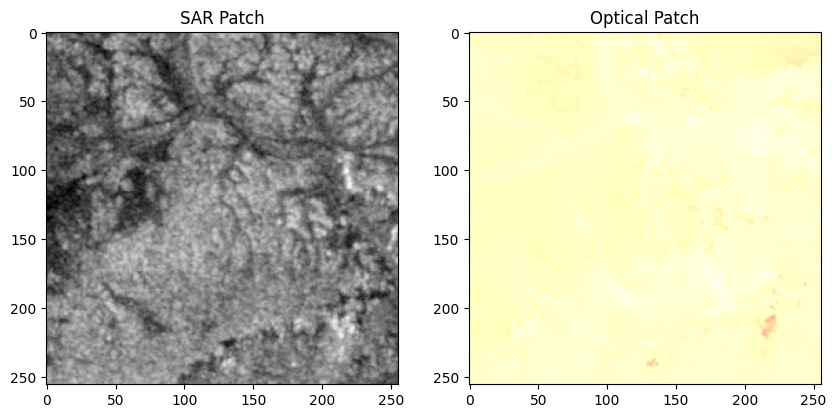

In [ ]:
# Check actual patch values
sar_sample, opt_sample = dataset[100]

print(f"SAR min/max: {sar_sample.min():.3f} / {sar_sample.max():.3f}")
print(f"Optical min/max: {opt_sample.min():.3f} / {opt_sample.max():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(sar_sample.squeeze().numpy(), cmap='gray')
axes[0].set_title('SAR Patch')

opt_show = ((opt_sample + 1) / 2).permute(1,2,0).numpy()
opt_show = np.clip(opt_show, 0, 1)
axes[1].imshow(opt_show)
axes[1].set_title('Optical Patch')

plt.show()

In [ ]:
# WE got a dataset problem : next approach is

In [ ]:
from google.colab import files
files.upload()  # upload kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d anjaliikakde/paired-sar-optical-dataset-16k-images

# Unzip to Drive
!unzip -q paired-sar-optical-dataset-16k-images.zip \
    -d /content/drive/MyDrive/SAR_Dataset/New_Data

print("✅ Download complete!")

# Check structure
import os
base = '/content/drive/MyDrive/SAR_Dataset/New_Data'
for root, dirs, files_list in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    if level < 3:
        print(' ' * 2 * level + os.path.basename(root) + '/')
        for f in files_list[:2]:
            print(' ' * 2 * (level+1) + f)

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/anjaliikakde/paired-sar-optical-dataset-16k-images
License(s): apache-2.0
100% 3.93G/3.93G [00:55<00:00, 76.2MB/s]

replace /content/drive/MyDrive/SAR_Dataset/New_Data/Paired_SAR_Optical_images/ROIs1868_summer_s1_59_p10.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
from PIL import Image
import torchvision.transforms as transforms
import torch
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np

class SAROpticalDataset(Dataset):
    def __init__(self, data_dir, img_size=256):
        self.data_dir = data_dir
        self.files = sorted([f for f in os.listdir(data_dir)
                           if f.endswith('.png')])
        self.img_size = img_size
        print(f"Found {len(self.files)} images")

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.files[idx])
        img = Image.open(img_path).convert('RGB')

        w, h = img.size
        half_w = w // 2

        # Split left (SAR) and right (Optical)
        sar_img = img.crop((0, 0, half_w, h))
        opt_img = img.crop((half_w, 0, w, h))

        # Resize
        resize = transforms.Resize((self.img_size, self.img_size))
        sar_img = resize(sar_img)
        opt_img = resize(opt_img)

        # Convert to tensor and normalize to [-1, 1]
        to_tensor = transforms.ToTensor()
        normalize = transforms.Normalize([0.5]*3, [0.5]*3)

        sar_tensor = normalize(to_tensor(sar_img))  # 3 channels
        opt_tensor = normalize(to_tensor(opt_img))  # 3 channels

        # SAR → 1 channel (grayscale)
        sar_tensor = sar_tensor.mean(dim=0, keepdim=True)

        return sar_tensor, opt_tensor


# =============================================
# Load Dataset
# =============================================
data_dir = '/content/drive/MyDrive/SAR_Dataset/New_Data/Paired_SAR_Optical_images'

dataset    = SAROpticalDataset(data_dir)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

# Test
sar_batch, opt_batch = next(iter(dataloader))
print(f"SAR shape:     {sar_batch.shape}")   # [4, 1, 256, 256]
print(f"Optical shape: {opt_batch.shape}")   # [4, 3, 256, 256]

# Visualize one sample
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sar_batch[0].squeeze().numpy(), cmap='gray')
axes[0].set_title('SAR Input')
axes[1].imshow(((opt_batch[0].permute(1,2,0).numpy() + 1) / 2))
axes[1].set_title('Optical Target')
plt.show()

print("✅ New dataset ready!")

In [ ]:
import torch.optim as optim
from torchvision.utils import save_image
import time
import os

# Fresh models
G = Generator().to(device)
D = Discriminator().to(device)

# Loss & Optimizers
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1  = nn.L1Loss()
optimizer_G   = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D   = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

LAMBDA_L1  = 100
NUM_EPOCHS = 50
save_dir   = '/content/drive/MyDrive/SAR_Dataset/Results_New'
os.makedirs(save_dir, exist_ok=True)
os.makedirs(f"{save_dir}/checkpoints", exist_ok=True)

print("🚀 Starting Training on 16K Dataset...")

for epoch in range(NUM_EPOCHS):
    G.train()
    D.train()
    epoch_loss_G = 0
    epoch_loss_D = 0
    start = time.time()

    for i, (sar, optical) in enumerate(dataloader):
        sar     = sar.to(device)
        optical = optical.to(device)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_pred   = D(sar, optical)
        real_labels = torch.ones_like(real_pred).to(device)
        loss_D_real = criterion_GAN(real_pred, real_labels)

        fake_optical = G(sar)
        fake_pred    = D(sar, fake_optical.detach())
        fake_labels  = torch.zeros_like(fake_pred).to(device)
        loss_D_fake  = criterion_GAN(fake_pred, fake_labels)

        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        fake_optical = G(sar)
        pred_fake    = D(sar, fake_optical)
        real_labels  = torch.ones_like(pred_fake).to(device)
        loss_G_GAN   = criterion_GAN(pred_fake, real_labels)
        loss_G_L1    = criterion_L1(fake_optical, optical) * LAMBDA_L1
        loss_G       = loss_G_GAN + loss_G_L1
        loss_G.backward()
        optimizer_G.step()

        epoch_loss_G += loss_G.item()
        epoch_loss_D += loss_D.item()

    elapsed = time.time() - start
    avg_G   = epoch_loss_G / len(dataloader)
    avg_D   = epoch_loss_D / len(dataloader)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"Loss_G: {avg_G:.4f}  "
          f"Loss_D: {avg_D:.4f}  "
          f"Time: {elapsed:.1f}s")

    if (epoch + 1) % 5 == 0:
        G.eval()
        with torch.no_grad():
            s_sar, s_opt = next(iter(dataloader))
            s_sar  = s_sar.to(device)
            fake   = G(s_sar)
            fake   = (fake + 1) / 2
            real   = (s_opt + 1) / 2
            save_image(fake, f"{save_dir}/fake_epoch_{epoch+1}.png")
            save_image(real, f"{save_dir}/real_epoch_{epoch+1}.png")
            print(f"💾 Saved samples at epoch {epoch+1}")

    if (epoch + 1) % 10 == 0:
        torch.save(G.state_dict(),
            f"{save_dir}/checkpoints/G_epoch_{epoch+1}.pth")
        torch.save(D.state_dict(),
            f"{save_dir}/checkpoints/D_epoch_{epoch+1}.pth")
        print(f"💾 Saved checkpoint at epoch {epoch+1}")

print("✅ Training Complete!")

🚀 Starting Training on 16K Dataset...
Epoch [1/50] Loss_G: 39.4837  Loss_D: 0.2924  Time: 770.6s
Epoch [2/50] Loss_G: 37.4124  Loss_D: 0.2916  Time: 771.0s
Epoch [3/50] Loss_G: 35.6389  Loss_D: 0.3077  Time: 770.3s
Epoch [4/50] Loss_G: 34.0426  Loss_D: 0.3030  Time: 770.5s
Epoch [5/50] Loss_G: 32.3846  Loss_D: 0.3070  Time: 770.7s
💾 Saved samples at epoch 5
Epoch [6/50] Loss_G: 30.6301  Loss_D: 0.3322  Time: 770.3s
Epoch [7/50] Loss_G: 29.4375  Loss_D: 0.3372  Time: 770.1s
Epoch [8/50] Loss_G: 28.3639  Loss_D: 0.3418  Time: 769.8s
Epoch [9/50] Loss_G: 27.5482  Loss_D: 0.3458  Time: 770.1s
Epoch [10/50] Loss_G: 26.7202  Loss_D: 0.3444  Time: 770.0s
💾 Saved samples at epoch 10
💾 Saved checkpoint at epoch 10
Epoch [11/50] Loss_G: 26.0825  Loss_D: 0.3453  Time: 769.8s
Epoch [12/50] Loss_G: 25.5029  Loss_D: 0.3445  Time: 771.0s
Epoch [13/50] Loss_G: 25.0442  Loss_D: 0.3406  Time: 771.1s
Epoch [14/50] Loss_G: 24.6584  Loss_D: 0.3337  Time: 770.2s


KeyboardInterrupt: 

✅ Model loaded!


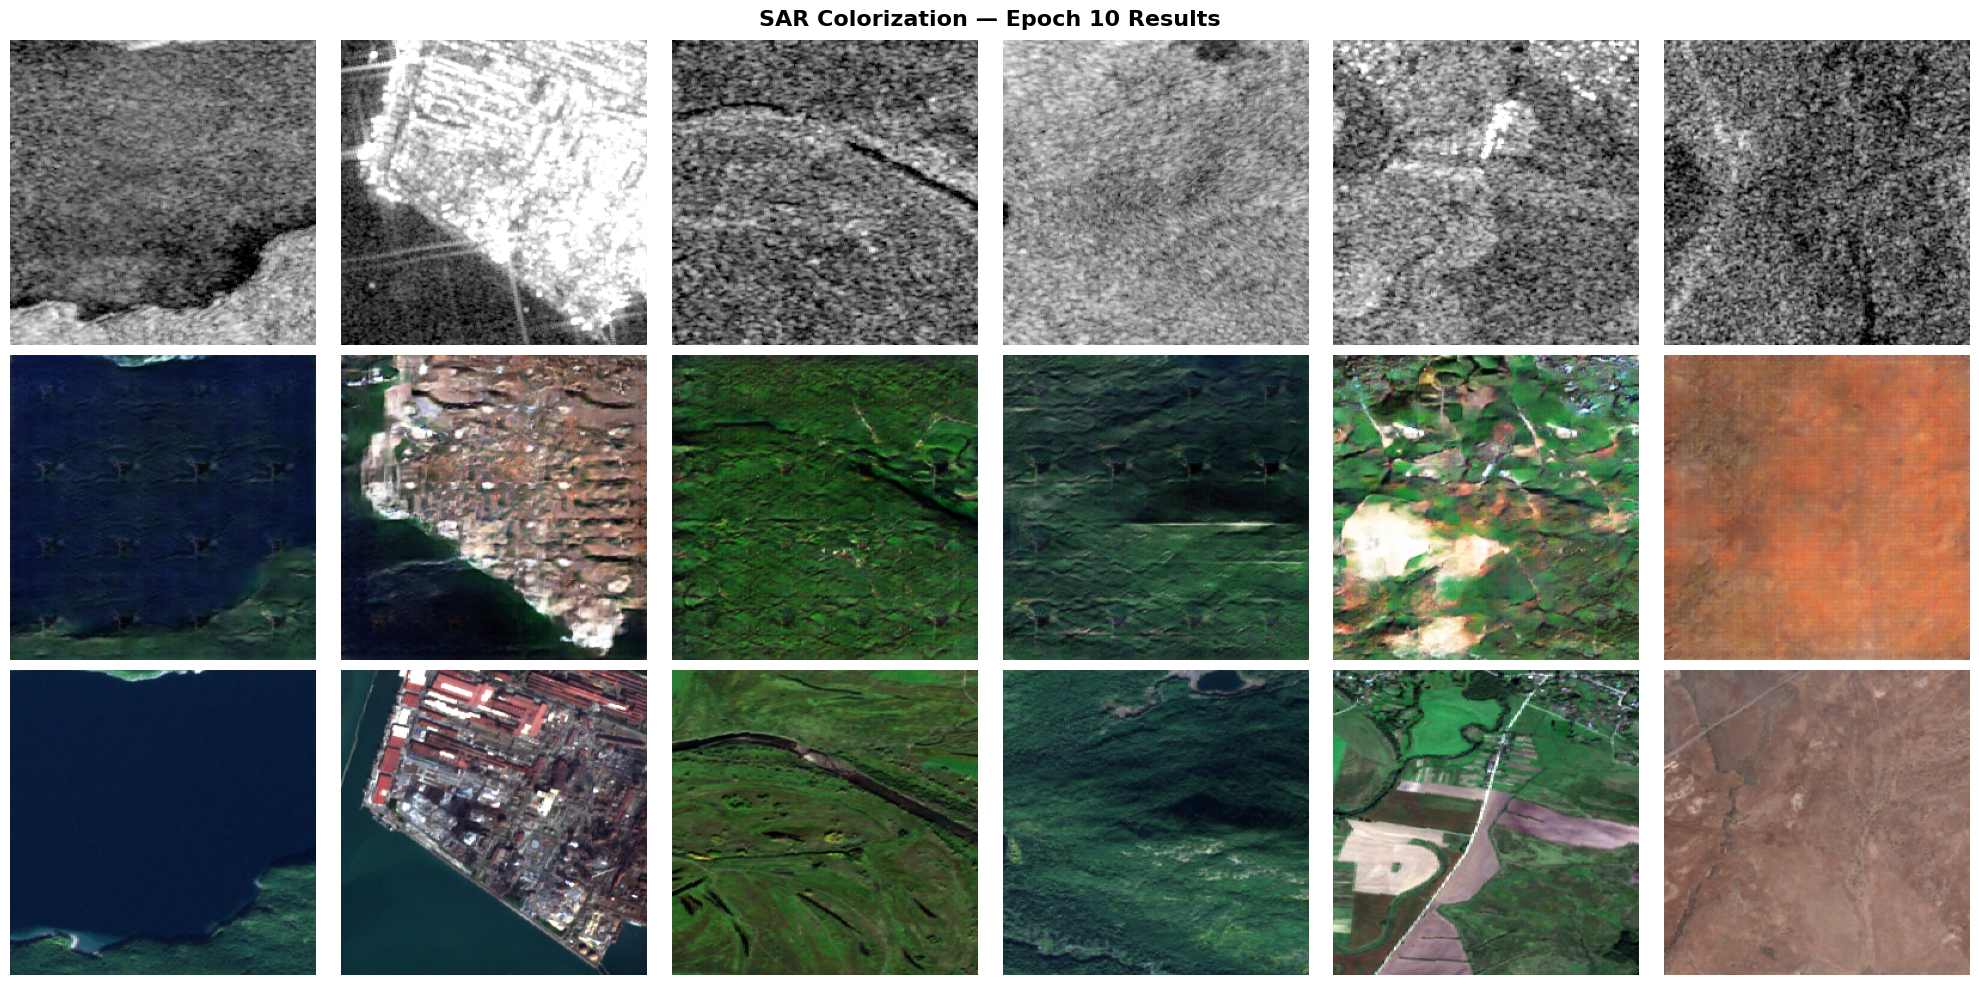

✅ Evaluation saved to Drive!

📊 Evaluation Metrics (200 samples):
PSNR : 15.88 dB  (higher is better, >20 is good)
SSIM : 0.2134     (higher is better, >0.6 is good)


In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torchvision.utils import save_image

# =============================================
# Load saved checkpoint
# =============================================
G_eval = Generator().to(device)
G_eval.load_state_dict(torch.load(
    '/content/drive/MyDrive/SAR_Dataset/Results_New/checkpoints/G_epoch_10.pth',
    map_location=device
))
G_eval.eval()
print("✅ Model loaded!")

# =============================================
# Evaluate on 6 samples
# =============================================
fig, axes = plt.subplots(3, 6, figsize=(20, 10))

row_titles = ['SAR Input', 'Generated Color', 'Ground Truth']

sample_count = 0
with torch.no_grad():
    for sar_batch, opt_batch in dataloader:
        sar_batch = sar_batch.to(device)
        fake_batch = G_eval(sar_batch)

        for i in range(min(4, sar_batch.size(0))):
            if sample_count >= 6:
                break

            # SAR
            sar_img = sar_batch[i].cpu().squeeze().numpy()
            axes[0, sample_count].imshow(sar_img, cmap='gray')
            axes[0, sample_count].axis('off')
            if sample_count == 0:
                axes[0, 0].set_ylabel('SAR Input', fontsize=12)

            # Generated
            fake_img = (fake_batch[i].cpu().permute(1,2,0).numpy() + 1) / 2
            fake_img = np.clip(fake_img, 0, 1)
            axes[1, sample_count].imshow(fake_img)
            axes[1, sample_count].axis('off')
            if sample_count == 0:
                axes[1, 0].set_ylabel('Generated', fontsize=12)

            # Ground Truth
            real_img = (opt_batch[i].cpu().permute(1,2,0).numpy() + 1) / 2
            real_img = np.clip(real_img, 0, 1)
            axes[2, sample_count].imshow(real_img)
            axes[2, sample_count].axis('off')
            if sample_count == 0:
                axes[2, 0].set_ylabel('Ground Truth', fontsize=12)

            sample_count += 1

        if sample_count >= 6:
            break

plt.suptitle('SAR Colorization — Epoch 10 Results',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SAR_Dataset/Results_New/evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Evaluation saved to Drive!")

# =============================================
# Calculate PSNR & SSIM
# =============================================
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

psnr_scores = []
ssim_scores = []

with torch.no_grad():
    for sar_batch, opt_batch in dataloader:
        sar_batch  = sar_batch.to(device)
        fake_batch = G_eval(sar_batch)

        for i in range(sar_batch.size(0)):
            fake = (fake_batch[i].cpu().permute(1,2,0).numpy() + 1) / 2
            real = (opt_batch[i].cpu().permute(1,2,0).numpy() + 1) / 2
            fake = np.clip(fake, 0, 1)
            real = np.clip(real, 0, 1)

            psnr_scores.append(psnr(real, fake, data_range=1.0))
            ssim_scores.append(ssim(real, fake,
                                    data_range=1.0,
                                    channel_axis=2))

        if len(psnr_scores) >= 200:  # Test on 200 samples
            break

print(f"\n📊 Evaluation Metrics (200 samples):")
print(f"PSNR : {np.mean(psnr_scores):.2f} dB  (higher is better, >20 is good)")
print(f"SSIM : {np.mean(ssim_scores):.4f}     (higher is better, >0.6 is good)")